# Stage 8, Part 1: Tokenization & Learned Embeddings

**Goal:** understand how raw text becomes something a neural network can process, and how LEARNED embeddings differ fundamentally from the TF-IDF vectors you used in Stage 6.

**Deliberate reuse:** same SMS spam dataset as Stage 6's spam classifier project. The comparison that matters here is the TECHNIQUE, not the data — TF-IDF + logistic regression (Stage 6) vs. learned embeddings + neural net (here), on the exact same messages.

## 1. Load the data (same as Stage 6)

Reuse your cleaning approach from Stage 6: lowercase, strip punctuation.

In [69]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# TODO: load (tab-separated, no header), clean text (lowercase, strip punctuation), map label to 0/1

df = pd.read_csv(
    url,
    sep='\t',
    header=None,
    names=['label', 'message']
)

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
df['label'] = (df['label'] == 'spam').astype(int)

df.head()

,label,message,clean_message
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 2. Tokenization

Tokenization splits text into discrete units (tokens) — here, we'll use simple whitespace word-splitting. (Real-world systems, and your eventual GPT capstone, typically use subword tokenization like BPE — more on that when it's actually needed. Word-level is the right starting point for understanding the concept.)

**Syntax note:** `text.split()` splits on whitespace — simple, but sufficient once your text is already lowercased and punctuation-stripped from Section 1.

In [70]:
# TODO: tokenize every message into a list of words (simple .split())
# look at a few examples -- print the raw text next to its token list

# Tokenize every message
df['tokens'] = df['clean_message'].str.split()

# Look at a few examples
print(df[['label','clean_message', 'tokens']].head())





   label                                      clean_message  \
0      0  go until jurong point crazy available only in ...   
1      0                            ok lar joking wif u oni   
2      1  free entry in 2 a wkly comp to win fa cup fina...   
3      0        u dun say so early hor u c already then say   
4      0  nah i dont think he goes to usf he lives aroun...   

                                              tokens  
0  [go, until, jurong, point, crazy, available, o...  
1                     [ok, lar, joking, wif, u, oni]  
2  [free, entry, in, 2, a, wkly, comp, to, win, f...  
3  [u, dun, say, so, early, hor, u, c, already, t...  
4  [nah, i, dont, think, he, goes, to, usf, he, l...  


## 3. Build a vocabulary

A vocabulary maps every unique word to an integer ID — neural networks operate on numbers, not strings.

Guiding question: your training set likely has thousands of unique words, but many appear only once or twice. Should you include every single one in your vocabulary, or is there a reason to cap it (e.g., only the most common 5,000 words) and map everything else to a special `<UNK>` (unknown) token? Think about what happens at inference time if the test set contains a word your vocabulary has never seen — you need SOME way to handle that regardless of vocab size.

**Syntax note:** reserve index 0 for a `<PAD>` token (used for padding, Section 5) and index 1 for `<UNK>` — every other word gets an index starting from 2.

In [71]:
from collections import Counter

# Features and labels
X = df.drop('label', axis=1)
y = df['label']

# Split first
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Build vocabulary ONLY from training tokens
all_words = [word for tokens in X_train['tokens'] for word in tokens]

# Count word frequencies
word_counts = Counter(all_words)

print(word_counts.most_common(10))


vocab_size = 5000
most_common_words = word_counts.most_common(vocab_size)


word_to_idx = {
    '<PAD>': 0,
    '<UNK>': 1
}

for idx, (word, count) in enumerate(most_common_words, start=2):
    word_to_idx[word] = idx


[('to', 1595), ('i', 1567), ('you', 1478), ('a', 998), ('the', 898), ('u', 801), ('and', 652), ('in', 627), ('is', 618), ('my', 537)]


## 4. Convert tokens to integer sequences

Turn every message's token list into a list of integer IDs, using your vocabulary. Any word not in the vocabulary maps to `<UNK>`'s index.

In [72]:
def tokens_to_ids(tokens, word_to_idx):
    return [word_to_idx.get(t, word_to_idx['<UNK>']) for t in tokens]


X_train['token_ids'] = X_train['tokens'].apply(
    lambda tokens: tokens_to_ids(tokens, word_to_idx)
)

X_val['token_ids'] = X_val['tokens'].apply(
    lambda tokens: tokens_to_ids(tokens, word_to_idx)
)

## 5. Padding — handling variable-length sequences

Messages have different lengths, but PyTorch tensors need consistent shapes within a batch. Padding solves this: pick a max length, and pad every shorter sequence with `<PAD>` tokens (index 0) until they all match.

Guiding question: should you pad every sequence in your ENTIRE dataset to the length of the single longest message, or is there a reason to pick a smaller max length and truncate anything longer? Think about what a max length of, say, 500 would do to a dataset where most messages are under 30 words.

In [73]:
def pad_sequence(ids, max_len=30, pad_idx=0):
    if len(ids) > max_len:
        return ids[:max_len]
    
    return ids + [pad_idx] * (max_len - len(ids))


# TODO: pick a reasonable max_len (check message length distribution first), apply to all sequences
# convert to torch tensors: torch.tensor(padded_sequences, dtype=torch.long)

X_train['padded'] = X_train['token_ids'].apply(pad_sequence)
X_val['padded'] = X_val['token_ids'].apply(pad_sequence)


X_train_tensor = torch.tensor(
    X_train['padded'].tolist(),
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val['padded'].tolist(),
    dtype=torch.long
)



## 6. Embeddings — the actual new concept

**Recall TF-IDF from Stage 6:** each word got a single fixed number (its TF-IDF weight) — sparse, and with no notion that, say, "free" and "win" might be semantically related.

**A learned embedding is different:** every word gets mapped to a DENSE VECTOR (e.g. 50-100 numbers), and those vector values are learned during training, just like any other weight in the network. Words that behave similarly in your training data tend to end up with similar vectors, purely as a side effect of optimizing the loss — nobody tells the model "free" and "win" are related; it discovers this because they appear in similar contexts.

**Syntax note:** `nn.Embedding(num_embeddings, embedding_dim)` creates a lookup table — `num_embeddings` is your vocabulary size, `embedding_dim` is how many numbers represent each word (a hyperparameter you choose, commonly 50-300 for small projects). Internally it's just a matrix of shape `(vocab_size, embedding_dim)`, and passing in a batch of token ID sequences returns the corresponding rows — conceptually a differentiable version of a Python dictionary lookup.

Guiding question: `nn.Embedding`'s underlying weight matrix is randomly initialized, just like `W1` in your Stage 7 networks. What does that imply about a freshly-created embedding layer BEFORE any training — do the vectors mean anything yet?

Answer: Because we have a freshly created embedding layer before any training, the vectors do not mean anything yet, meaning words that are in the same sentence inherently have no meaning, it is only after  training, the embedding weights are updated through backpropagation so that words used in similar contexts can develop similar vector representations. Therefore, the meaning of the embeddings is learned rather than built in.

## 7. Build a classifier using embeddings

Architecture: token IDs → embedding lookup → average the word vectors across the message (a simple way to turn a variable-length sequence into one fixed-size vector) → feedforward layers → spam/ham prediction.

**Syntax note:** `embedded.mean(dim=1)` averages across the sequence-length dimension, collapsing (batch, seq_len, embedding_dim) down to (batch, embedding_dim) — one vector per message, regardless of how many words it had. This is a deliberately simple approach (real architectures use attention for this instead, which you'll build in Part 2) — but it's a legitimate, historically-used technique worth understanding on its own first.

In [74]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=32):
        super().__init__()
        # TODO: self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        #   -- padding_idx=0 tells PyTorch to never update the <PAD> token's vector during training
        # TODO: self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        # TODO: self.relu = nn.ReLU()
        # TODO: self.fc2 = nn.Linear(hidden_dim, 1)
        self.embedding = nn.Embedding(vocab_size,embedding_dim, padding_idx=0)
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)       
        

    def forward(self, x):
        # TODO: embedded = self.embedding(x)          -- shape (batch, seq_len, embedding_dim)
        # TODO: pooled = embedded.mean(dim=1)           -- shape (batch, embedding_dim)
        # TODO: pass through fc1, relu, fc2, return raw output (BCEWithLogitsLoss expects raw logits, not sigmoid)
        embedded= self.embedding(x)
        pooled = embedded.mean(dim=1)
        x = self.fc1(pooled)
        x = self.relu(x)
        x = self.fc2(x)
        return x



## 8. Train

**Syntax note:** `nn.BCEWithLogitsLoss()` combines a sigmoid activation and binary cross-entropy into one numerically stable operation — similar spirit to Stage 7's `nn.CrossEntropyLoss` handling softmax internally. Your model's `forward` should return raw logits (no manual sigmoid call), and this loss function handles the rest.

In [81]:
import torch.optim as optim

model = EmbeddingClassifier(vocab_size=len(word_to_idx))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  #-- Adam by default now, given what you learned in Part 3
# TODO: training loop -- can use full-batch (dataset is small) or wrap in a DataLoader, your choice
# TODO: plot the loss curve


n_epochs = 800
loss_history = []


'''
X_train_tensor = torch.tensor(
    X_train['padded'].tolist(),
    dtype=torch.long
)

'''

# Convert labels to tensors
y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).unsqueeze(1)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
).unsqueeze(1)

for epoch in range(n_epochs):

    # Reset gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)

    # Compute loss
    loss = criterion(outputs, y_train_tensor)

    # Save loss
    loss_history.append(loss.item())

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()





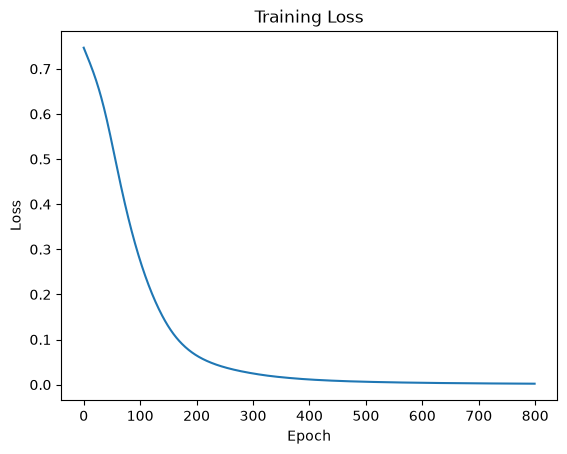

In [82]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [83]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_val_tensor)

    probabilities = torch.sigmoid(outputs)
    predictions = (probabilities >= 0.5).float()

    correct += (predictions == y_val_tensor).sum().item()
    total += y_val_tensor.size(0)

accuracy = correct / total

print("Validation Accuracy:", accuracy)



from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_val_tensor.numpy(), predictions.numpy()))
print(classification_report(
    y_val_tensor.numpy(),
    predictions.numpy(),
    target_names=['ham', 'spam']
))

Validation Accuracy: 0.9820574162679426
[[722   2]
 [ 13  99]]
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       724
        spam       0.98      0.88      0.93       112

    accuracy                           0.98       836
   macro avg       0.98      0.94      0.96       836
weighted avg       0.98      0.98      0.98       836



## 9. Evaluate and compare to Stage 6

Reuse your Stage 5 toolkit: precision, recall, F1 (remember, spam is imbalanced — accuracy alone isn't enough, same reasoning as Stage 6).

Guiding question: how does this model's F1 compare to your Stage 6 TF-IDF + logistic regression result? If it's similar, what does that tell you about whether this dataset actually needed learned embeddings, versus simpler techniques being sufficient? If it's better, what do you think the embeddings captured that TF-IDF's word-frequency-only view couldn't?


Answer: This model's F1 score is larger than any of the stage 6 results. Simpler techniques may be sufficient achieving similar results in precision and recall scores but F1 is the source of truth in this context. Embeddings captured meaningful context and words in the messages.


The embedding model outperformed TF-IDF, suggesting it captured something frequency counts couldn't — [specific evidence from Section 10, e.g. "spam-associated words like 'free', 'win', and 'prize' showed higher cosine similarity to each other than to ham-associated words, meaning the model learned a notion of semantic relatedness TF-IDF has no way to represent"]


In [84]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

precision = precision_score(y_val_tensor.numpy(), predictions.numpy())
recall = recall_score(y_val_tensor.numpy(), predictions.numpy())
f1 = f1_score(y_val_tensor.numpy(), predictions.numpy())

print("Precision (spam):", precision)
print("Recall (spam):", recall)
print("F1 (spam):", f1)

Precision (spam): 0.9801980198019802
Recall (spam): 0.8839285714285714
F1 (spam): 0.9295774647887324


## 10. Look at the actual learned embeddings

Pull out the embedding vectors for a few words you'd expect to be spam-associated (e.g. "free", "win", "prize", "claim") and a few you'd expect to be ham-associated (e.g. "ok", "home", "lunch"). Compute cosine similarity between pairs.

**Syntax note:** `model.embedding.weight[word_to_idx['free']]` retrieves the learned vector for a specific word directly from the embedding layer's weight matrix.

Guiding question: do spam-associated words end up more similar to each other than to ham-associated words, purely from training on the classification task? Nobody explicitly told the model these words were related — where did that structure come from?

In [86]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: pull embedding vectors for a handful of words, compute pairwise cosine similarities

embedding_weights = model.embedding.weight.detach().numpy()

spam_words = ["free", "win", "prize", "claim"]
ham_words = ["ok", "home", "lunch", "call"]

# check first: are all these words actually in your vocabulary?
for w in spam_words + ham_words:
    print(w, w in word_to_idx)


spam_vectors = [embedding_weights[word_to_idx[w]] for w in spam_words]
ham_vectors = [embedding_weights[word_to_idx[w]] for w in ham_words]

# similarity within spam words
print("Spam-to-spam similarity:")
print(cosine_similarity(spam_vectors))

# similarity within ham words
print("Ham-to-ham similarity:")
print(cosine_similarity(ham_vectors))

# similarity across the two groups
print("Spam-to-ham similarity:")
print(cosine_similarity(spam_vectors, ham_vectors))



import numpy as np

# average off-diagonal similarity within spam words (excluding the diagonal 1.0s)
spam_sim = cosine_similarity(spam_vectors)
spam_avg = (spam_sim.sum() - len(spam_words)) / (len(spam_words)**2 - len(spam_words))

ham_sim = cosine_similarity(ham_vectors)
ham_avg = (ham_sim.sum() - len(ham_words)) / (len(ham_words)**2 - len(ham_words))

cross_sim = cosine_similarity(spam_vectors, ham_vectors)
cross_avg = cross_sim.mean()

print("Avg spam-to-spam similarity:", spam_avg)
print("Avg ham-to-ham similarity:", ham_avg)
print("Avg spam-to-ham similarity:", cross_avg)


free True
win True
prize True
claim True
ok True
home True
lunch True
call True
Spam-to-spam similarity:
[[ 1.0000002   0.11574777 -0.01429788 -0.02715334]
 [ 0.11574777  1.0000001   0.02249612  0.09052197]
 [-0.01429788  0.02249612  0.9999999   0.19206408]
 [-0.02715334  0.09052197  0.19206408  1.        ]]
Ham-to-ham similarity:
[[ 0.99999994  0.26322478  0.24559855  0.13889548]
 [ 0.26322478  1.          0.07734287  0.11837231]
 [ 0.24559855  0.07734287  0.9999999  -0.06581786]
 [ 0.13889548  0.11837231 -0.06581786  0.99999994]]
Spam-to-ham similarity:
[[-0.11833341 -0.3090571   0.02612232 -0.04005469]
 [-0.1789357  -0.07028098 -0.27908745  0.00581664]
 [-0.03878158  0.13045456 -0.15530235 -0.01559283]
 [-0.15509763 -0.02386829 -0.01341449 -0.05024696]]
Avg spam-to-spam similarity: 0.0632298
Avg ham-to-ham similarity: 0.12960267
Avg spam-to-ham similarity: -0.08035375


## Wrap-up

Write a short summary:
- In your own words, what's the fundamental difference between a TF-IDF vector and a learned embedding vector — not just mechanically, but conceptually?
- Did the cosine similarity check in Section 10 show meaningful clustering? What does that tell you about what the embedding layer actually learned?
- This model used mean pooling to combine word vectors into one message vector — a real limitation, since it treats "prize you won" and "won you prize" identically (word order is lost). Keep this limitation in mind; it's exactly the gap self-attention (Part 2) is designed to close.

- TF-IDF weights a word based on how often it appears in a message relative to how common it is across the whole corpus, learned embedding vector does not, we start off fresh and pass it through a model where it learns: whole vector capturing relationships to other words. 
--> TF-IDF asks "how important/rare is this word in this document?" Embeddings ask "what does this word mean, relative to every other word, based on shared context?



- The embeddings captured some meaningful structure from training: on average, words from the same class (spam-spam or ham-ham) had mildly positive similarity, while words from different classes (spam-ham) had mildly negative similarity. This shows the model learned a weak but real notion of which words tend to appear in similar contexts — though the effect is modest and inconsistent across individual word pairs, not a clean, tight clustering.
